In [2]:
import glob, os, re, sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import scienceplots
from classy import Class

plt.style.use(['science', 'no-latex', 'vpedre'])

In [73]:
kk = np.array([1e-3, 1e-2, 1e-1])

base = {
    # 'H0'      : 67,
    # 'Omega_b' : 0.049,
    # 'Omega_cdm': 0.27,
    # 'A_s'     : 2.6e-9,
    # 'n_s'     : 0.96,
    # 'k_pivot' : 0.05,
    'output'  : 'tCl mPk dTk vTk',
    'k_output_values': ','.join([str(k) for k in kk]),
    'z_max_pk': 5,
    # 'evolver': 0,
}

def class_w0wa(w0, wa):
    p = dict(base)
    p.update({'Omega_Lambda': 0, 'w0_fld': w0, 'wa_fld': wa, 'cs2_fld': 1.})
    return p

def mochi_w0wa(w0, wa):
    """GR-limit scalar field with CPL expansion history."""
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/gr.dat',
        'parameters_smg': '1e-10',
        'expansion_model': 'w0wa',
        'expansion_smg' : f'0.67, {w0}, {wa}',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p

def mochi_frhs():
    """HS f(R) with CPL expansion history using background-consistent stable_params."""
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/hs_fr_stable_params_fr0_1em4_n_1_mathematica.dat',
        'parameters_smg': '6.061178756035e-5',
        'expansion_model': 'rho_de',
        'expansion_smg' : '0.67',
        'expansion_file_name' : '../stable_params_input/rho_de_stable_hs_fr_n_1_fr0_1em4_mathematica.dat',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p

def mochi_cgal():
    p = dict(base)
    p.update({
        'Omega_Lambda'  : 0,
        'Omega_fld'     : 0,
        'Omega_smg'     : -1,
        'gravity_model' : 'stable_params',
        'smg_file_name' : '../stable_params_input/cubic_galileon_stable_params_mathematica.dat',
        'parameters_smg': '1.380051990990777',
        'expansion_model': 'rho_de',
        'expansion_smg' : '0.67',
        'expansion_file_name' : '../stable_params_input/rho_de_stable_cubic_galileon_mathematica.dat',
        'method_qs_smg' : 'automatic',
        'method_gr_smg' : 'on',
        'z_gr_smg'      : 99.,
    })
    return p


w0_values = np.array([-1.3, -1.0, -0.7])
wa_values = np.array([-0.6, 0.0, 0.6])

w0_values = np.array([-1.0])
wa_values = np.array([0.0])

W0, Wa = np.meshgrid(w0_values, wa_values)
models_to_run = {}

for w0, wa in zip(W0.ravel(), Wa.ravel()):
    models_to_run[f'lcdm_w0={w0}_wa={wa}']      = class_w0wa(w0, wa)
    models_to_run[f'mochi_lcdm_w0={w0}_wa={wa}'] = mochi_w0wa(w0, wa)
    
models_to_run[f'mochi_frhs'] = mochi_frhs()
models_to_run[f'mochi_cgal'] = mochi_cgal()


In [74]:
cosmo = {}
bk    = {}
pt    = {}

for name, pars in models_to_run.items():
    print(f'Computing {name}...', end=' ', flush=True)
    cosmo[name] = Class()
    cosmo[name].set(pars)
    # try:
    cosmo[name].compute()
    # except:
        # print('problem')
        # continue
    bk[name] = cosmo[name].get_background()
    pt[name] = cosmo[name].get_perturbations()['scalar']
    print('done')

Computing lcdm_w0=-1.0_wa=0.0... done
Computing mochi_lcdm_w0=-1.0_wa=0.0... done
Computing mochi_frhs... done
Computing mochi_cgal... done


In [75]:
rho_frhs = bk['mochi_frhs']['(.)rho_smg']
zz_frhs = bk['mochi_frhs']['z']

rho_cgal = bk['mochi_cgal']['(.)rho_smg']
zz_cgal = bk['mochi_cgal']['z']

rho_lcdm = bk['lcdm_w0=-1.0_wa=0.0']['(.)rho_fld']
zz_lcdm = bk['lcdm_w0=-1.0_wa=0.0']['z']

rho_mochi_lcdm = bk['mochi_lcdm_w0=-1.0_wa=0.0']['(.)rho_smg']
zz_mochi_lcdm = bk['mochi_lcdm_w0=-1.0_wa=0.0']['z']

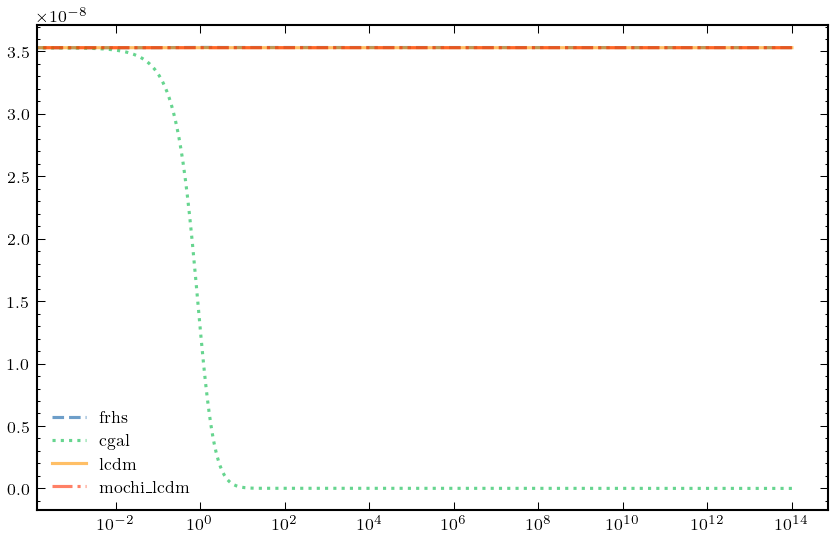

In [76]:
fig, ax = plt.subplots()

ax.semilogx(zz_frhs,        rho_frhs,       alpha=0.6, ls='--', label='frhs')
ax.semilogx(zz_cgal,        rho_cgal,       alpha=0.6, ls=':', label='cgal')
ax.semilogx(zz_lcdm,        rho_lcdm,       alpha=0.6, ls='-' , label='lcdm')
ax.semilogx(zz_mochi_lcdm,  rho_mochi_lcdm, alpha=0.6, ls='-.', label='mochi_lcdm')

ax.legend()

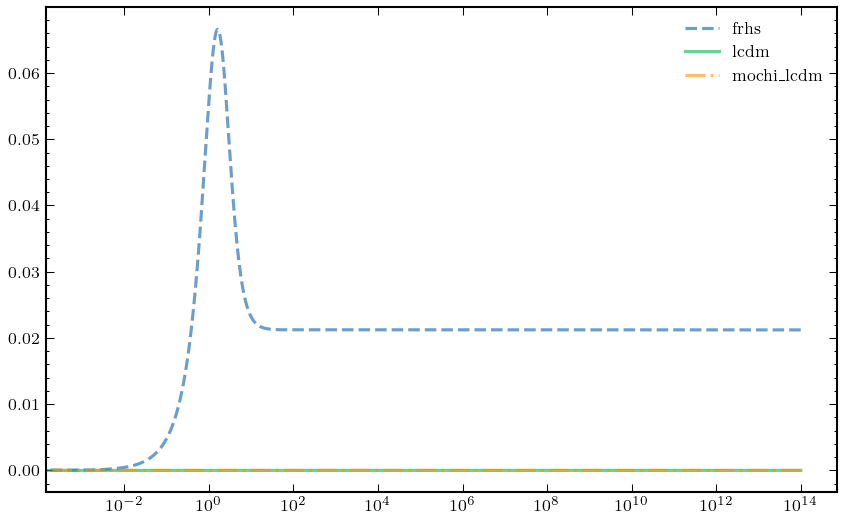

In [77]:
fig, ax = plt.subplots()

ax.semilogx(zz_frhs,       100*(rho_frhs/rho_lcdm[0]-1)      ,   alpha=0.6, ls='--', label='frhs')
# ax.semilogx(zz_cgal,       100*(rho_cgal/rho_lcdm[0]-1)      ,   alpha=0.6, ls=':', label='cgal')
ax.semilogx(zz_lcdm,       100*(rho_lcdm/rho_lcdm[0]-1)      ,   alpha=0.6, ls='-' , label='lcdm')
ax.semilogx(zz_mochi_lcdm, 100*(rho_mochi_lcdm/rho_lcdm[0]-1),   alpha=0.6, ls='-.', label='mochi_lcdm')

ax.legend()

In [86]:
def plot_de_pert(pert_key, k_idx=0, skip='black'):
    fig, ax = plt.subplots()

    for model in models_to_run.keys():
        if skip in model:
            continue
        if 'mochi' in model:
            aa      = pt[model][k_idx]['a']
            pert    = pt[model][k_idx][f'{pert_key}_smg']#/pt[model][k_idx][f'{pert_key}_smg'][-1]
            label=model
        else:
            aa      = pt[model][k_idx]['a']
            try:
                pert    = pt[model][k_idx][f'{pert_key}_fld']#/pt[model][k_idx][f'{pert_key}_fld'][-1]
            except:
                pert = np.zeros_like(aa)
            label='lcdm'
        ax.semilogx(aa, pert, label=label)
        ax.set_title(pert_key)
    ax.legend()


def plot_de(k_idx=0, skip='None'):
    fig, axes = plt.subplots(1, 3, figsize=(14,4))

    for model in models_to_run.keys():
        d = pt[model][k_idx]
        if skip in model:
            continue
        if 'mochi' not in model:
            aa = d['a']
            try:
                delta   = d['delta_fld']
                theta   = d['theta_fld']
                shear   = d['shear_fld']
            except:
                delta = np.zeros_like(aa)
                theta = np.zeros_like(aa)
                shear = np.zeros_like(aa)
            label = r'\texttt{CLASS} $\Lambda$CDM'
        else:
            aa      = d['a']
            delta   = d['delta_smg']
            theta   = d['theta_smg']
            shear   = d['shear_smg']
            lbl = model.split('_')[1]
            if lbl == 'lcdm':
                label = r'\texttt{mochi} $\Lambda$CDM'
            elif lbl == 'frhs':
                label = r'\texttt{mochi} $f(R)$ HS'
            else:
                label = r'\texttt{mochi} cGalileon'
            
        axes[0].semilogx(aa, delta, label=label)
        axes[1].semilogx(aa, theta, label=label)
        axes[2].semilogx(aa, shear, label=label)
        
        for ax, title in zip(axes, [r'$\delta_{\rm DE}(a)$', r'$\theta_{\rm DE}(a)$', r'$\sigma_{\rm DE}(a)$']):
            ax.set_xlabel('Scale factor $a$')
            ax.set_title(title)
            ax.legend()
    fig.suptitle(rf'Evolution of Dark Energy Perturbations for $k={kk[k_idx]}$ ' r'Mpc$^{-1}$')

    # ax.legend()

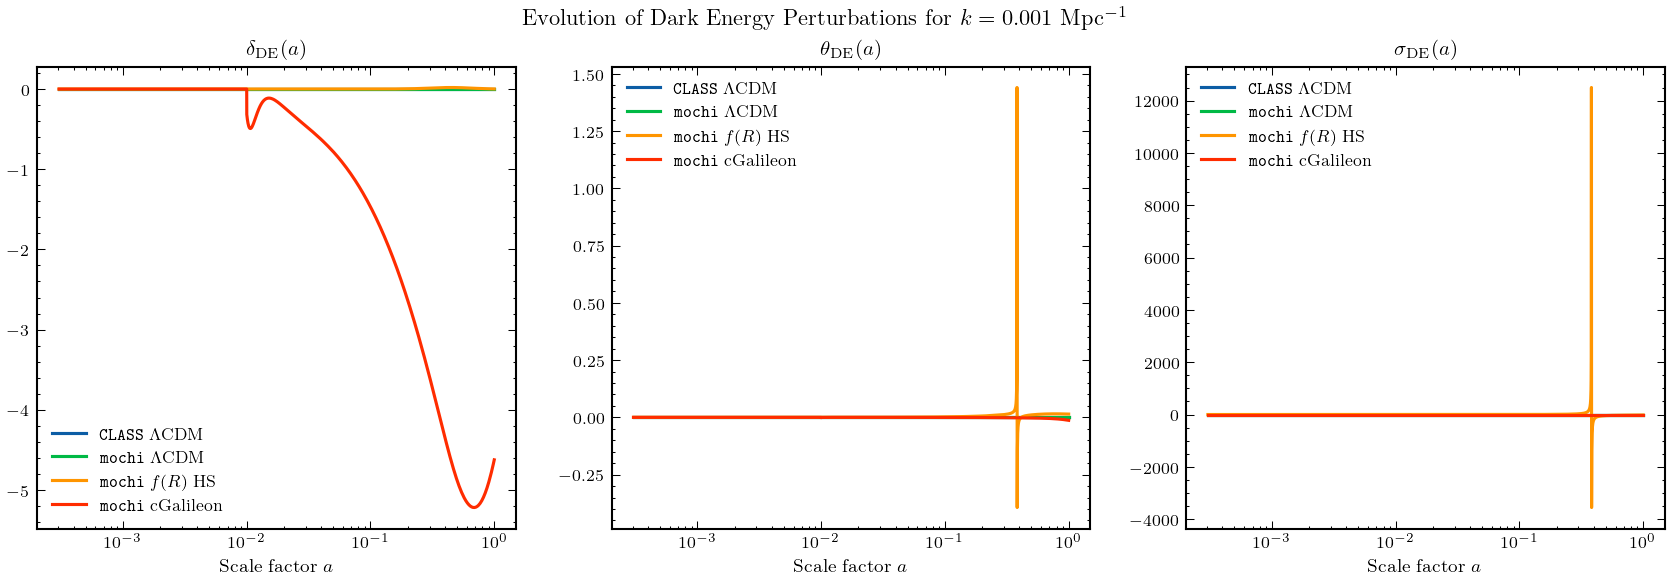

In [87]:
plot_de()

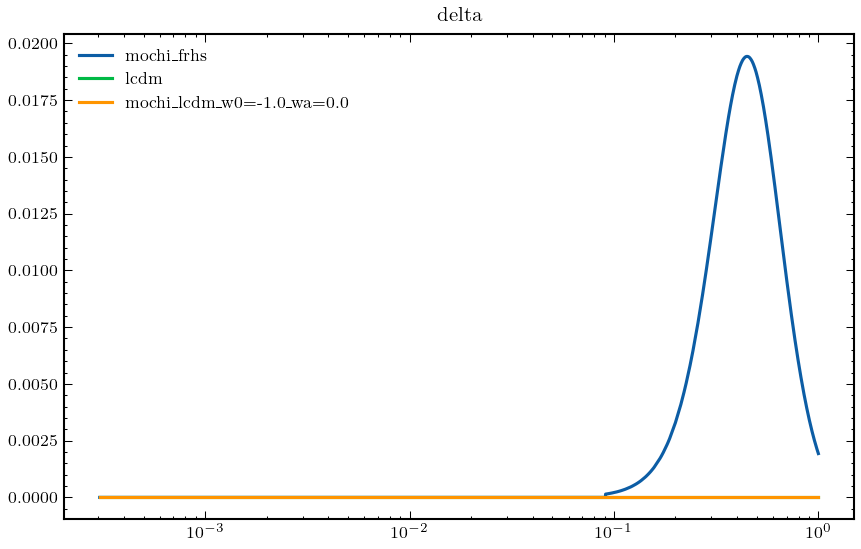

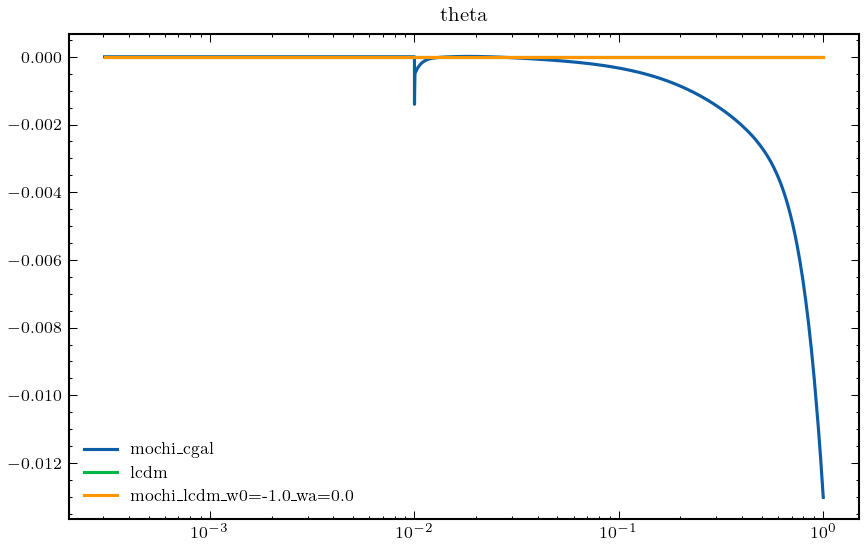

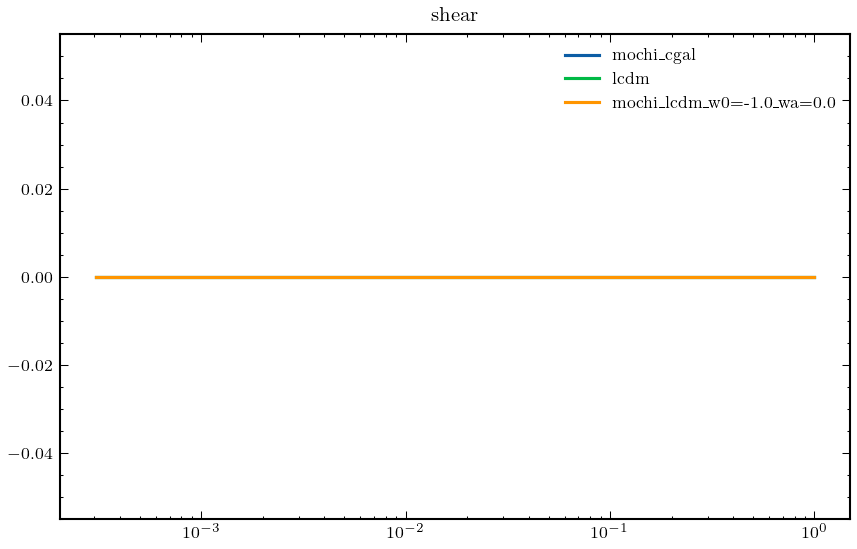

In [11]:
plot_de_pert('delta', k_idx=0, skip='cgal')
plot_de_pert('theta', k_idx=0, skip='frhs')
plot_de_pert('shear', k_idx=0, skip='frhs')

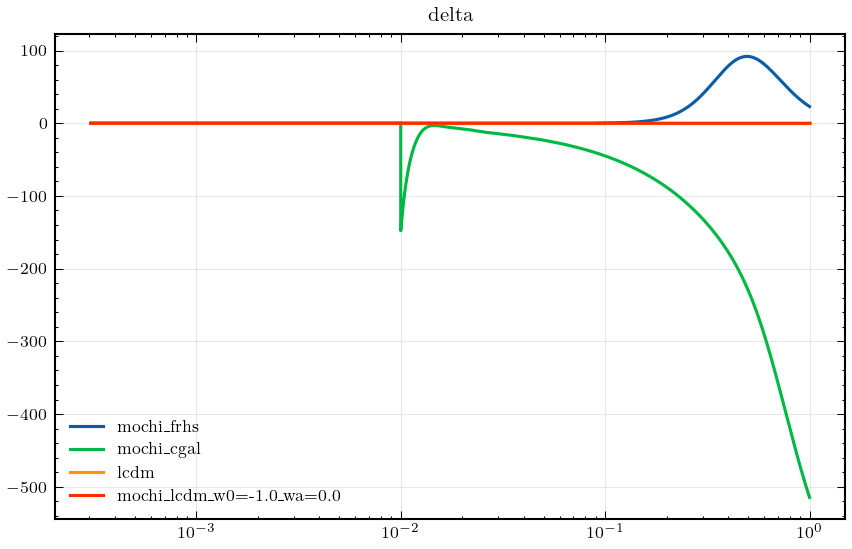

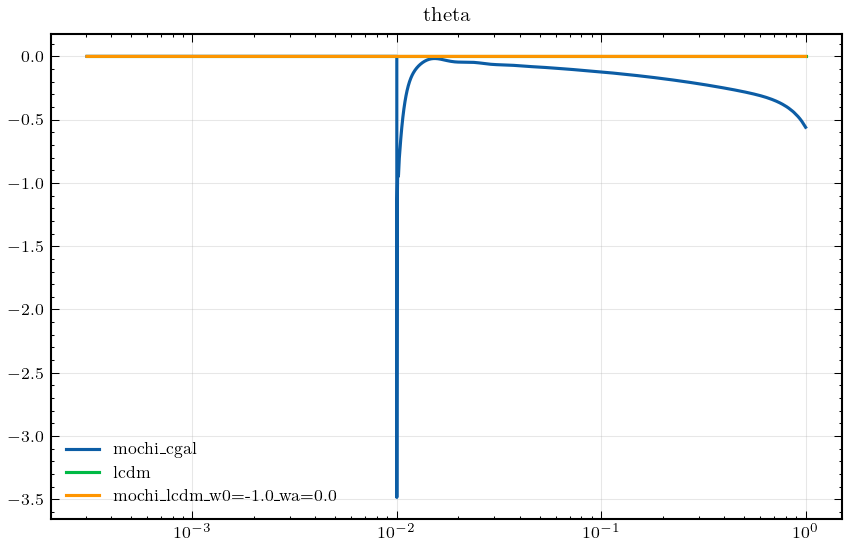

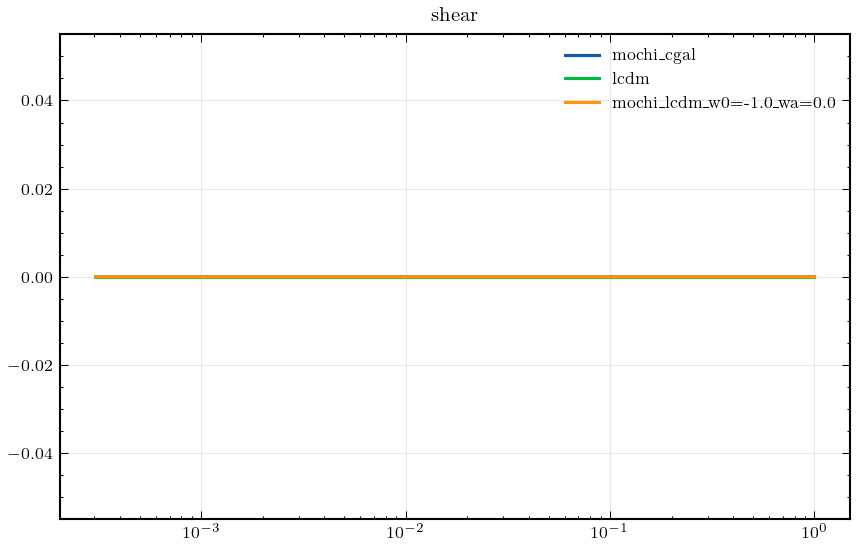

In [100]:
plot_de_pert('delta', k_idx=1, skip='black')
plot_de_pert('theta', k_idx=1, skip='frhs')
plot_de_pert('shear', k_idx=1, skip='frhs')

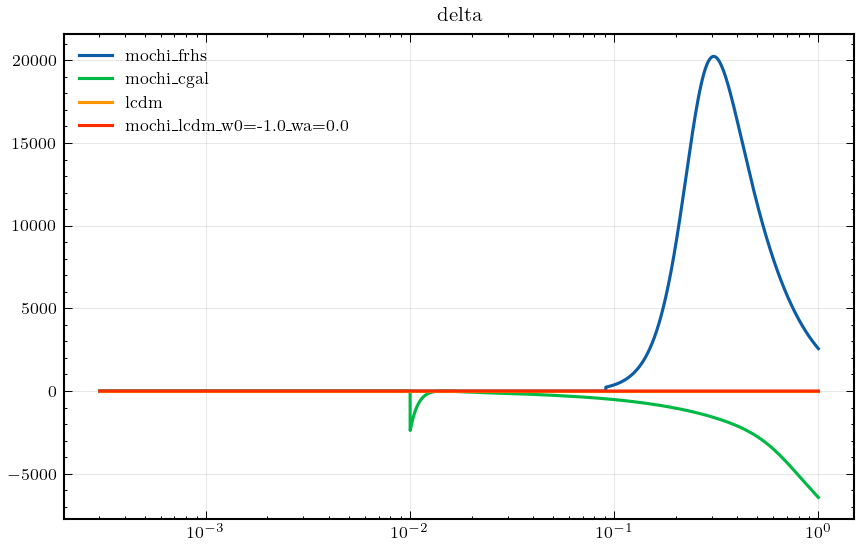

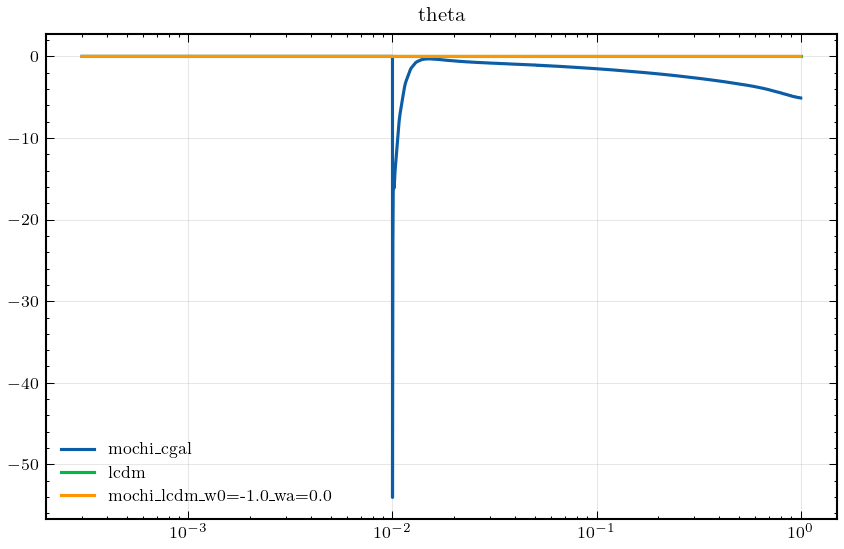

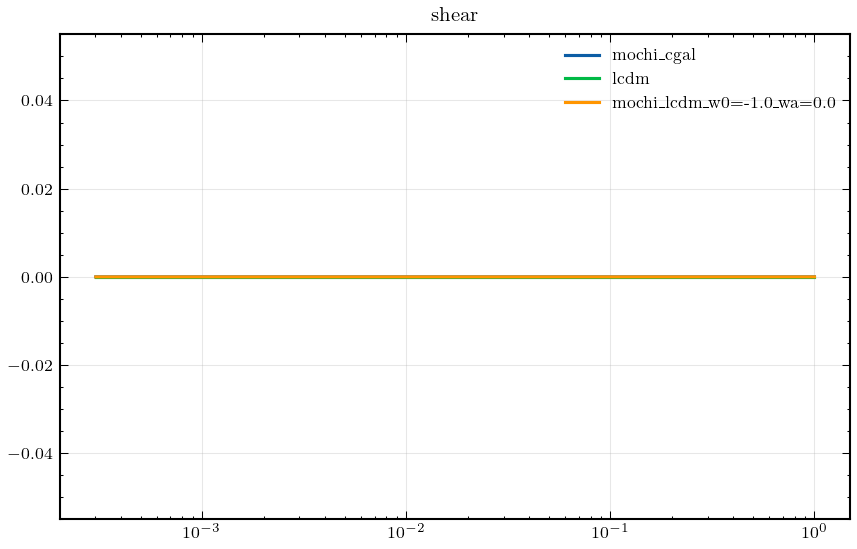

In [101]:
plot_de_pert('delta', k_idx=2, skip='black')
plot_de_pert('theta', k_idx=2, skip='frhs')
plot_de_pert('shear', k_idx=2, skip='frhs')

KeyError: 'shear_fld'

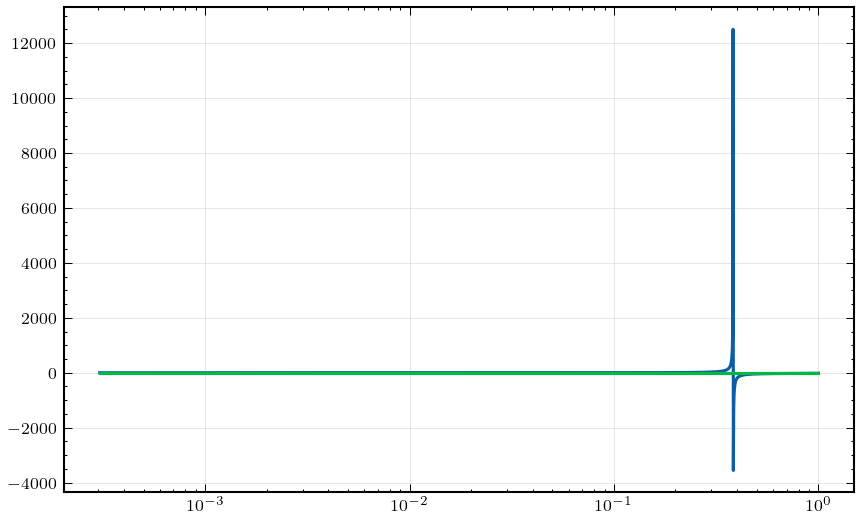

In [ ]:
plot_de_pert('shear')

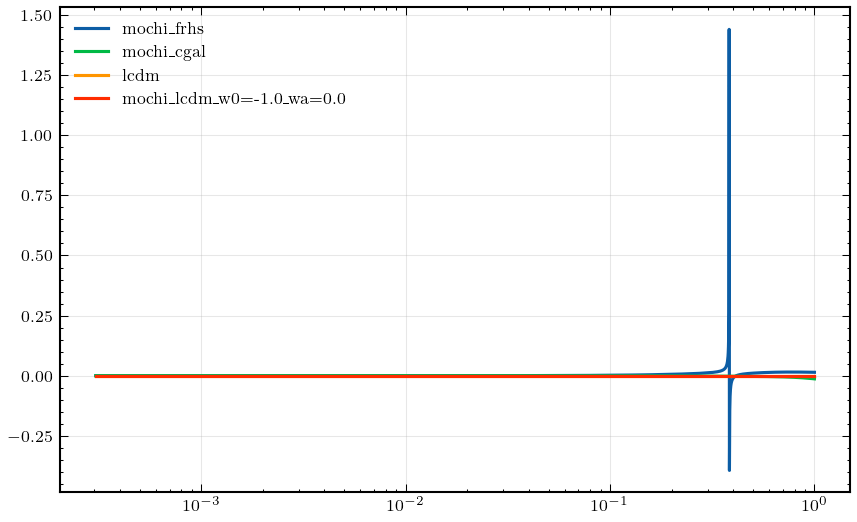

In [ ]:
plot_de_pert('theta',)

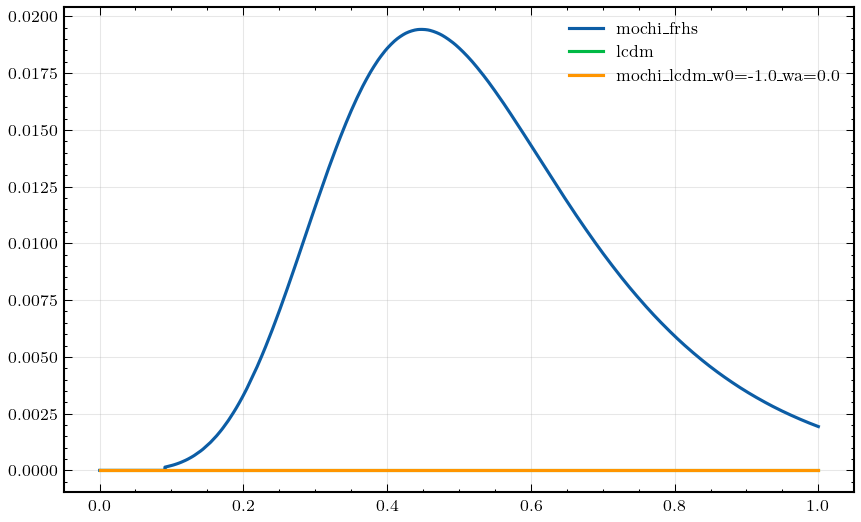

In [ ]:
fig, ax = plt.subplots()

for k_idx in np.arange(1):
    for model in models_to_run.keys():
        if 'cgal' in model:
            continue
        if 'mochi' in model:
            delta_rho       = pt[model][k_idx]['delta_smg']
            aa              = pt[model][k_idx]['a']
            label=model
        else:
            delta_rho       = pt[model][k_idx]['delta_fld']
            aa              = pt[model][k_idx]['a']
            label='lcdm'
        ax.plot(aa, delta_rho, label=label)
        
ax.legend()


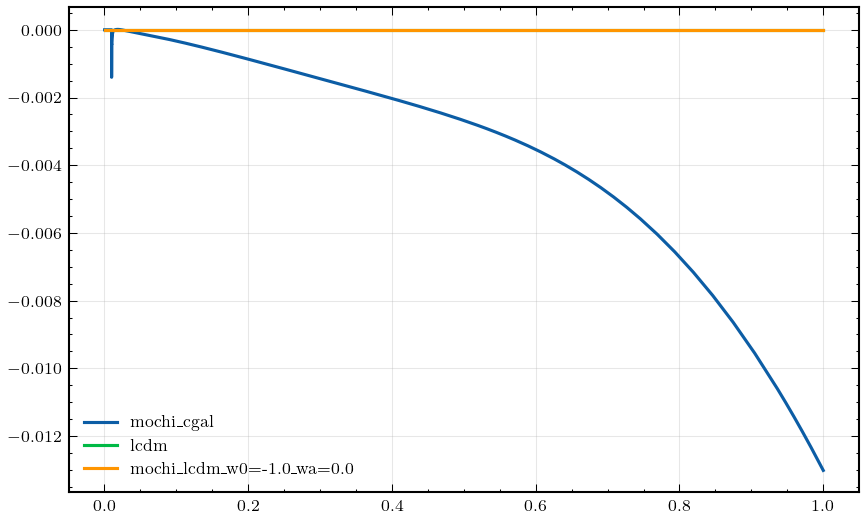

In [63]:
pert_key = 'theta'

fig, ax = plt.subplots()

for k_idx in np.arange(1):
    for model in models_to_run.keys():
        if 'frhs' in model:
            continue
        if 'mochi' in model:
            delta_rho       = pt[model][k_idx][pert_key+'_smg']
            aa              = pt[model][k_idx]['a']
            label=model
        else:
            delta_rho       = pt[model][k_idx][pert_key+'_fld']
            aa              = pt[model][k_idx]['a']
            label='lcdm'
        ax.plot(aa, delta_rho, label=label)
        
ax.legend()


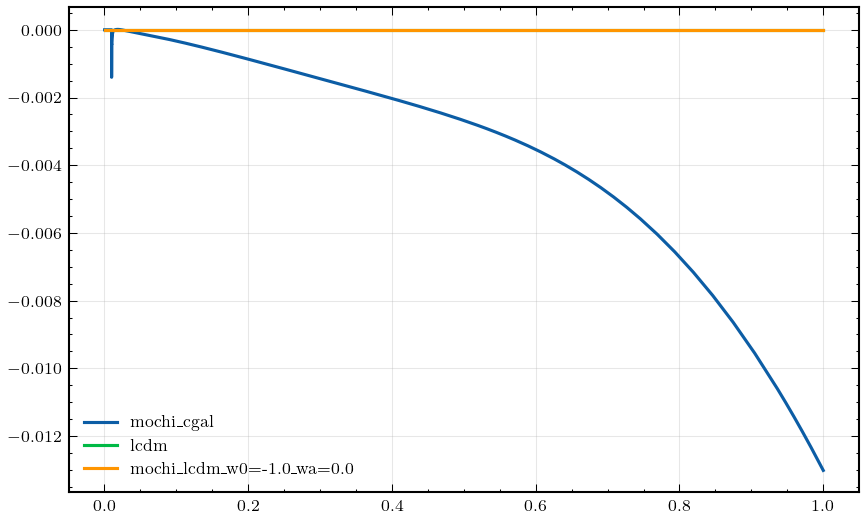

In [64]:
pert_key = 'theta'

fig, ax = plt.subplots()

for k_idx in np.arange(1):
    for model in models_to_run.keys():
        if 'frhs' in model:
            continue
        if 'mochi' in model:
            delta_rho       = pt[model][k_idx][pert_key+'_smg']
            aa              = pt[model][k_idx]['a']
            label=model
        else:
            delta_rho       = pt[model][k_idx][pert_key+'_fld']
            aa              = pt[model][k_idx]['a']
            label='lcdm'
        ax.plot(aa, delta_rho, label=label)
        
ax.legend()
